# 4 Qubits

In [1]:
import sys
sys.path.append("./src")

import importlib
# import src.metrics
import src.dashboard
importlib.reload(src.dashboard)
# importlib.reload(src.metrics)

from src.metrics import *
from src.visualization import visualize_aligned_samples
from src.dashboard import *
from src.circuits import *
from src.noises import *
from src.generate_and_save_datasets import *

In [2]:
import random
import numpy as np
import torch
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

##### Tests

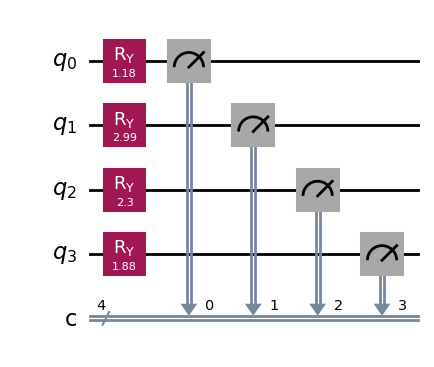

In [3]:
# INDEPENDENT CIRCUIT:
import numpy as np
thetas = np.random.uniform(0, np.pi, size=4)
qc_ind = build_circuit_independent(thetas,measure=True)
qc_ind.draw('mpl')

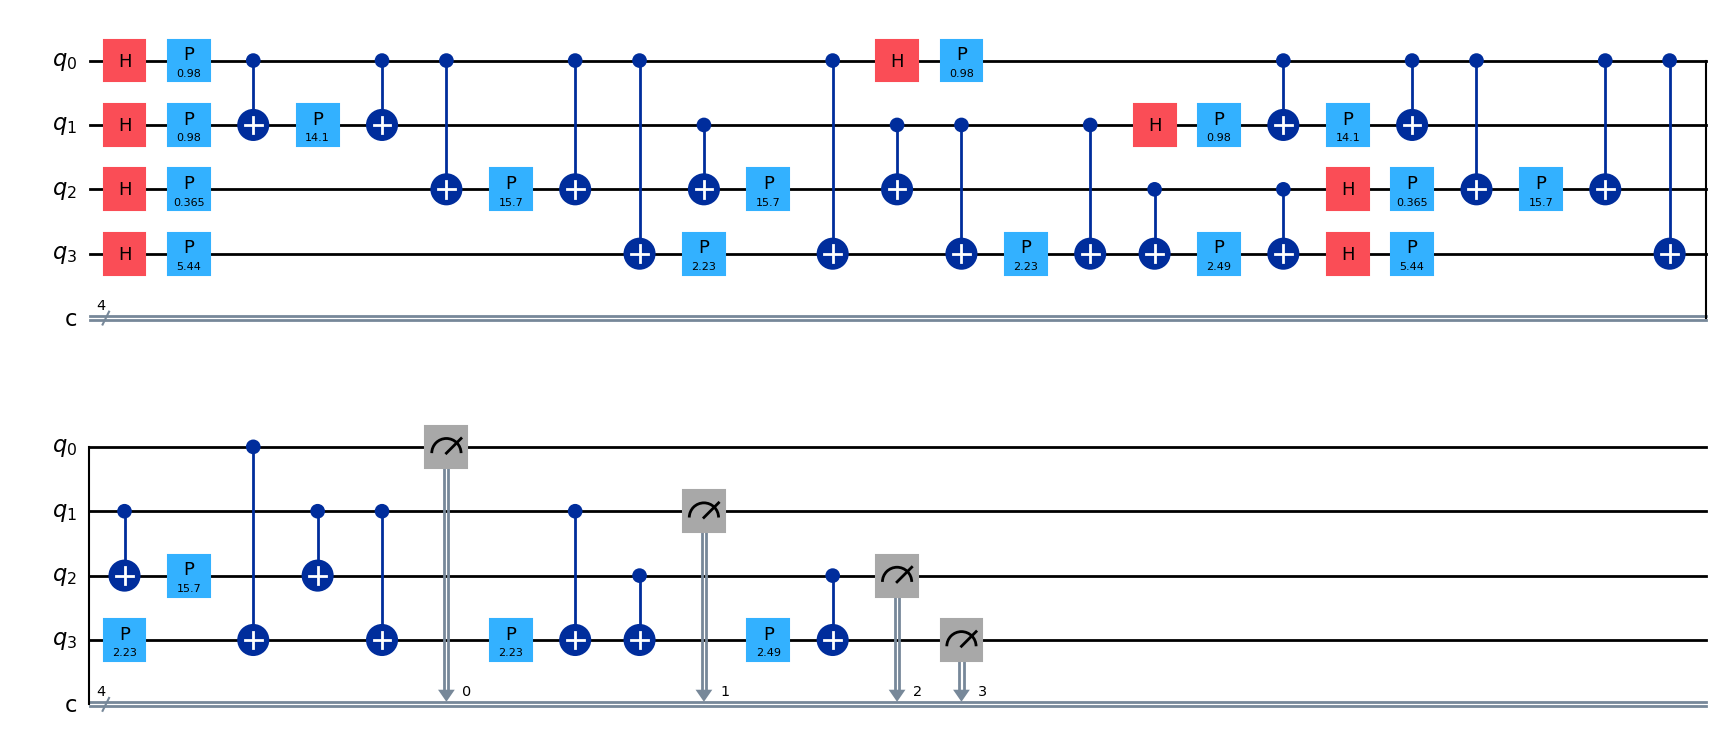

In [4]:
# ZZ FeatureMap CIRCUIT:
# from qiskit.circuit.library import zz_feature_map
thetas = np.random.uniform(0, np.pi, size=4)
qc_zzfm = build_zzfeaturemap_circuit(thetas,reps=2,entanglement="full", measure=True)
qc_zzfm.draw('mpl')

In [5]:
# qc.append(zz_feature_map(2,1),[0,1])
# qc.decompose().draw('mpl')
# qc.assign_parameters({qc.parameters[0]: 0.5, qc.parameters[1]: 0.5})

In [6]:
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError
from qiskit import transpile
from qiskit.circuit import QuantumCircuit
qc = QuantumCircuit(4,4)
qc.measure([0,1,2,3],[0,1,2,3])
noise_model = create_noise_model(
    mode="experimental_correlated")

sim = AerSimulator(noise_model=noise_model)
qc_t = transpile(qc,sim,optimization_level=0,
    initial_layout=[0,1,2,3])
result = sim.run(qc_t,shots=10000).result()

counts = result.get_counts()

print(counts)

{'0000': 10000}


In [7]:
qc = QuantumCircuit(4,4)
qc.measure([0,1,2,3],[0,1,2,3])

sim = AerSimulator()

qc_t = transpile(qc, sim)

result = sim.run(qc_t, shots=100000).result()

counts = result.get_counts()

p_ideal = counts_to_probs_4q(counts)

print("Ideal:")
print(p_ideal)

p_noisy = apply_correlated_readout_noise(p_ideal)

print("\nNoisy:")
print(np.round(p_noisy,3))

Ideal:
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Noisy:
[0.626 0.126 0.059 0.008 0.066 0.009 0.008 0.001 0.063 0.018 0.008 0.001
 0.003 0.002 0.001 0.001]


### Run All Phases

#### Phase 0 / Baseline 
<!-- prediction = X_noisy
target     = Y_ideal -->


Identity Model

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
class IdentityModel(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return x
model_base = IdentityModel()     # For synthetic circuit 
model_base_zz = IdentityModel()  # For zz feature circuit

In [9]:
import pandas as pd
from src.evaluation import evaluate_model

results_0 = {}
noise_modes = ["synthetic","experimental_single",
    "experimental_correlated"]
for noise_mode in noise_modes:
    X_test, Y_test, TH_test = load_dataset(
        split="test", circuit_type="independent",
        noise_mode=noise_mode)
    results_0[noise_mode] = evaluate_model(
        model_base,  X_test, Y_test)
rows = []
for noise_mode, metrics in results_0.items():
    rows.append({"Dataset": noise_mode,
        "FidelityMean": metrics["fidelity_mean"],
        "L1 Mean": metrics["l1_mean"],"KL Mean": metrics["kl_mean"] })
df_0 = pd.DataFrame(rows)
print("phase 0 (no training): Independent circuit")
print("==========================================================")
print(df_0.round(3))

phase 0 (no training): Independent circuit
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.907    0.367    0.137
1      experimental_single         0.768    0.707    0.386
2  experimental_correlated         0.763    0.714    0.398


#### Phase 1
<!-- - TRAIN:
    - independent + synthetic

- VALIDATION:
    - independent + synthetic

- TEST:
    - independent + all noises     -->

Train on independent circuit -Ry- using synthetic noise models and test on all noises.

In [57]:
X_train_1, Y_train_1, TH_train_1 = load_dataset(
    split="train",circuit_type="independent",
    noise_mode="synthetic")
X_val_1, Y_val_1, TH_val_1 = load_dataset(
    split="validation",circuit_type="independent",
    noise_mode="synthetic")
# Test — synthetic
X_test_syn_1, Y_test_syn_1, TH_test_syn_1 = load_dataset(
    split="test",circuit_type="independent",
    noise_mode="synthetic")
# Test — experimental single
X_test_single_1, Y_test_single_1, TH_test_single_1 = load_dataset(
    split="test",circuit_type="independent",
    noise_mode="experimental_single")
# Test — experimental correlated
X_test_corr_1, Y_test_corr_1, TH_test_corr_1 = load_dataset(
    split="test",circuit_type="independent",
    noise_mode="experimental_correlated")

In [11]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_1, dtype=torch.float32),
        torch.tensor(Y_train_1, dtype=torch.float32)),
        batch_size=BATCH_SIZE,shuffle=True)
# Validation Loader
val_loader = DataLoader(
    TensorDataset( torch.tensor(X_val_1, dtype=torch.float32),
        torch.tensor(Y_val_1, dtype=torch.float32)),
        batch_size=BATCH_SIZE, shuffle=False)

In [12]:
import torch
import torch.nn as nn
class MLP_4Q(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(16, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 16),
            nn.Softmax(dim=1)
            # nn.LogSoftmax(dim=1)
              )
    def forward(self, x):
        return self.net(x)

In [13]:
model_phase1 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase1.parameters(),
    lr=1e-3)
EPOCHS = 61
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase1.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase1(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase1.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase1(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

# model_phase1 = MLP_4Q()
# # criterion = nn.KLDivLoss(reduction="batchmean")
# criterion = nn.MSELoss()
# optimizer = torch.optim.Adam(
#     model_phase1.parameters(),
#     lr=1e-3)
# EPOCHS = 101
# train_losses = []
# val_losses = []
# for epoch in range(EPOCHS):
#     # TRAIN
#     # =====================================================
#     model_phase1.train()
#     running_loss = 0.0
#     for xb, yb in train_loader:
#         optimizer.zero_grad()
#         preds = model_phase1(xb)
#         loss = criterion(preds, yb)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item()
#     train_loss = running_loss / len(train_loader)
#     # VALIDATION
#     # =====================================================
#     model_phase1.eval()
#     val_running_loss = 0.0
#     with torch.no_grad():
#         for xb, yb in val_loader:
#             preds = model_phase1(xb)
#             loss = criterion(preds, yb)
#             val_running_loss += loss.item()
#     val_loss = val_running_loss / len(val_loader)
#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
#     if epoch % 10 == 0:
#         print( f"Epoch {epoch} | "
#             f"Train Loss = {train_loss:.6f} | "
#             f"Val Loss = {val_loss:.6f}" )

Epoch 0 | Train Loss = 0.8417 | Val Loss = 0.1330
Epoch 10 | Train Loss = 0.0522 | Val Loss = 0.0535
Epoch 20 | Train Loss = 0.0385 | Val Loss = 0.0402
Epoch 30 | Train Loss = 0.0341 | Val Loss = 0.0356
Epoch 40 | Train Loss = 0.0334 | Val Loss = 0.0373
Epoch 50 | Train Loss = 0.0331 | Val Loss = 0.0355
Epoch 60 | Train Loss = 0.0328 | Val Loss = 0.0344


In [18]:
from src.evaluation import evaluate_model
import pandas as pd

# Phase 1: train on Synthetic -> test on Synthetic only (matched)
res = evaluate_model(model_phase1, X_test_syn_1, Y_test_syn_1)
df_1 = pd.DataFrame([{
    "Dataset": "synthetic",
    "FidelityMean": round(res["fidelity_mean"], 3),
    "L1 Mean": round(res["l1_mean"], 3),
    "KL Mean": round(res["kl_mean"], 3),
}])
print("==========================================================")
print("phase 1: Independent | matched train/test: Synthetic")
print(df_1)

phase 1: Independent | matched train/test: Synthetic
     Dataset  FidelityMean  L1 Mean  KL Mean
0  synthetic         0.979    0.147    0.034


In [19]:
import importlib
import src.visualization

importlib.reload(src.visualization)

from src.visualization import visualize_aligned_samples

Shared indices: [1116]


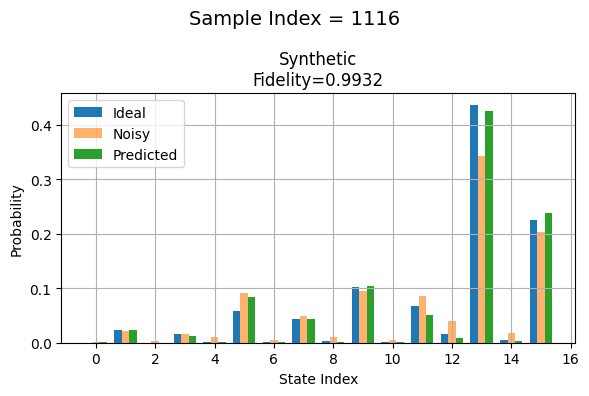

In [20]:
import importlib
import src.visualization
importlib.reload(src.visualization)
from src.visualization import visualize_aligned_samples

visualize_aligned_samples(model_phase1,
    datasets={"Synthetic":(X_test_syn_1, Y_test_syn_1)}, # other tests also possible!
    n_samples=1)

# visualize_aligned_samples(model_phase1,
#     X_test_syn_1, Y_test_syn_1,
#     X_test_single_1, Y_test_single_1,
#     X_test_corr_1, Y_test_corr_1,
#     n_samples=1)


##### TEST fidelity befor TRAINING

In [21]:
# Fidelity before executing the training! 
raw_fidelity = np.mean([
    fidelity(Y_test_syn_1[i], X_test_syn_1[i])
    for i in range(len(X_test_syn_1))])
print(raw_fidelity)


0.9072323893272527


#### Phase 2

phase 2_0:
Ry Circuit and train experimental single!

In [22]:
X_train_2, Y_train_2, TH_train_2 = load_dataset(
    split="train",circuit_type="independent",
    noise_mode="experimental_single")
X_val_2, Y_val_2, TH_val_2 = load_dataset(
    split="validation",circuit_type="independent",
    noise_mode="experimental_single")
# Test — experimental single
X_test_single_2, Y_test_single_2, TH_test_single_2 = load_dataset(
    split="test",circuit_type="independent",
    noise_mode="experimental_single")

In [23]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_2, dtype=torch.float32),
        torch.tensor(Y_train_2, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)
# Validation Loader
val_loader = DataLoader(
    TensorDataset( torch.tensor(X_val_2, dtype=torch.float32),
        torch.tensor(Y_val_2, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [24]:
model_phase2_0 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase2_0.parameters(),
    lr=1e-3)
EPOCHS = 61
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase2_0.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase2_0(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase2_0.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase2_0(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 1.0116 | Val Loss = 0.5047
Epoch 10 | Train Loss = 0.0588 | Val Loss = 0.0593
Epoch 20 | Train Loss = 0.0553 | Val Loss = 0.0560
Epoch 30 | Train Loss = 0.0535 | Val Loss = 0.0543
Epoch 40 | Train Loss = 0.0534 | Val Loss = 0.0554
Epoch 50 | Train Loss = 0.0526 | Val Loss = 0.0518
Epoch 60 | Train Loss = 0.0510 | Val Loss = 0.0519


In [25]:
# # Plot 
# plt.figure(figsize=(4,2))
# plt.plot(train_losses, label="Train")
# plt.plot(val_losses,
#          label="Validation Experimental Single")
# plt.xlabel("Epoch")
# plt.ylabel("KL Loss")
# plt.title("Training Curve (Circuit: Ry, Noise: Synthetic)")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()

In [26]:
from src.evaluation import evaluate_model
import pandas as pd
# Phase 2_0: train on Experimental Single -> test on Experimental Single only
res = evaluate_model(model_phase2_0, X_test_single_2, Y_test_single_2)
df_2_0 = pd.DataFrame([{
    "Dataset": "experimental_single",
    "FidelityMean": round(res["fidelity_mean"], 3),
    "L1 Mean": round(res["l1_mean"], 3),
    "KL Mean": round(res["kl_mean"], 3),
}])
print("phase 2_0: Independent | matched train/test: Experimental Single")
print("==========================================================")
print(df_2_0)

phase 2_0: Independent | matched train/test: Experimental Single
               Dataset  FidelityMean  L1 Mean  KL Mean
0  experimental_single         0.968     0.19     0.05


Shared indices: [1116]


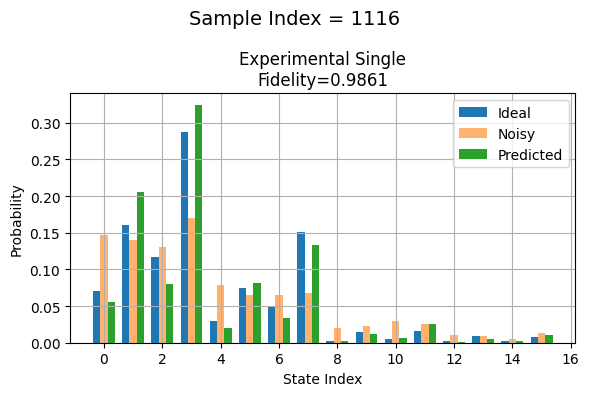

In [27]:
visualize_aligned_samples(model_phase2_0,
    datasets={"Experimental Single":(X_test_single_2, Y_test_single_2)},
    n_samples=1)

##### phase 2_1:
Ry Circuit and train correlated datasets!

In [ ]:
X_train_2_1, Y_train_2_1, TH_train_2_1 = load_dataset(
    split="train",circuit_type="independent",
    noise_mode="experimental_correlated")
X_val_2_1, Y_val_2_1, TH_val_2_1 = load_dataset(
    split="validation",circuit_type="independent",
    noise_mode="experimental_correlated")

X_test_corr_2_1, Y_test_corr_2_1, TH_test_corr_2_1 = load_dataset(
    split="test",circuit_type="independent",
    noise_mode="experimental_correlated")

In [29]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_2_1, dtype=torch.float32),
        torch.tensor(Y_train_2_1, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)
# Validation Loader
val_loader = DataLoader(
    TensorDataset( torch.tensor(X_val_2_1, dtype=torch.float32),
        torch.tensor(Y_val_2_1, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [30]:
model_phase2_1 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase2_1.parameters(),
    lr=1e-3)
EPOCHS = 61
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase2_1.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase2_1(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        # loss = criterion(preds, yb )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase2_1.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase2_1(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            # loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 0.9625 | Val Loss = 0.3841
Epoch 10 | Train Loss = 0.0497 | Val Loss = 0.0500
Epoch 20 | Train Loss = 0.0446 | Val Loss = 0.0450
Epoch 30 | Train Loss = 0.0383 | Val Loss = 0.0390
Epoch 40 | Train Loss = 0.0323 | Val Loss = 0.0322
Epoch 50 | Train Loss = 0.0271 | Val Loss = 0.0292
Epoch 60 | Train Loss = 0.0240 | Val Loss = 0.0250


In [31]:
from src.evaluation import evaluate_model
import pandas as pd

# Phase 2_1: train on Experimental Correlated -> test on Experimental Correlated only
res = evaluate_model(model_phase2_1, X_test_corr_2_1, Y_test_corr_2_1)
df_2_1 = pd.DataFrame([{
    "Dataset": "experimental_correlated",
    "FidelityMean": round(res["fidelity_mean"], 3),
    "L1 Mean": round(res["l1_mean"], 3),
    "KL Mean": round(res["kl_mean"], 3),
}])
print("phase 2_1: Independent | matched train/test: Experimental Correlated")
print("==========================================================")
print(df_2_1)

phase 2_1: Independent | matched train/test: Experimental Correlated
                   Dataset  FidelityMean  L1 Mean  KL Mean
0  experimental_correlated         0.984    0.117    0.024


Shared indices: [1116]


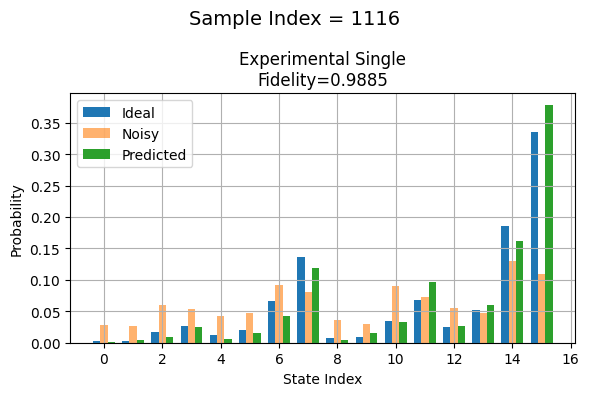

In [32]:
visualize_aligned_samples(model_phase2_1,
    datasets={"Experimental Single":(X_test_corr_2_1, Y_test_corr_2_1)},
    n_samples=1)

#### Phase 3_0 
- TRAIN:
    - zzfeaturemap + synthetic  


- VALIDATION:
    - zzfeaturemap + synthetic

- TEST:
    - zzfeaturemap + experimental_single
    - zzfeaturemap + experimental_correlated 
    - zzfeaturemap  + synthetic 

In [59]:
X_train_30, Y_train_30, TH_train_30 = load_dataset(
    split="train",circuit_type="zz_featuremap",
    noise_mode="synthetic")
X_val_30, Y_val_30, TH_val_30 = load_dataset(
    split="validation",circuit_type="zz_featuremap",
    noise_mode="synthetic")
# Test 
X_test_syn_30, Y_test_syn_30, TH_test_syn_30 = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="synthetic")
# Test 
X_test_single_30, Y_test_single_30, TH_test_single_30 = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_single")# Test 
X_test_corr_30, Y_test_corr_30, TH_test_corr_30 = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [34]:
# Fidelity before executing the training! 
raw_fidelity30 = np.mean([
    fidelity(Y_test_syn_30[i], X_test_syn_30[i])
    for i in range(len(X_test_syn_30))])
print(raw_fidelity30)

0.9380133486414691


In [35]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_30, dtype=torch.float32),
        torch.tensor(Y_train_30, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)

val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_30, dtype=torch.float32),
        torch.tensor(Y_val_30, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [36]:
model_phase3_0 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase3_0.parameters(),
    lr=1e-3)
EPOCHS = 61
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase3_0.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase3_0(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        # loss = criterion(preds, yb )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase3_0.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase3_0(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            # loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 0.4809 | Val Loss = 0.4440
Epoch 10 | Train Loss = 0.1067 | Val Loss = 0.1078
Epoch 20 | Train Loss = 0.0616 | Val Loss = 0.0643
Epoch 30 | Train Loss = 0.0505 | Val Loss = 0.0533
Epoch 40 | Train Loss = 0.0466 | Val Loss = 0.0511
Epoch 50 | Train Loss = 0.0444 | Val Loss = 0.0497
Epoch 60 | Train Loss = 0.0434 | Val Loss = 0.0481


In [37]:
results_30 = {}
results_30["synthetic"] = evaluate_model(
    model_phase3_0,X_test_syn_30,Y_test_syn_30)

import pandas as pd
rows = []
for name, res in results_30.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_3_0 = pd.DataFrame(rows)
print("phase 3_0: circuit zz, Noise: synthetic")
print('==========================================================')
print(df_3_0)

phase 3_0: circuit zz, Noise: synthetic
     Dataset  FidelityMean  L1 Mean  KL Mean
0  synthetic         0.973    0.205    0.047


Shared indices: [1116]


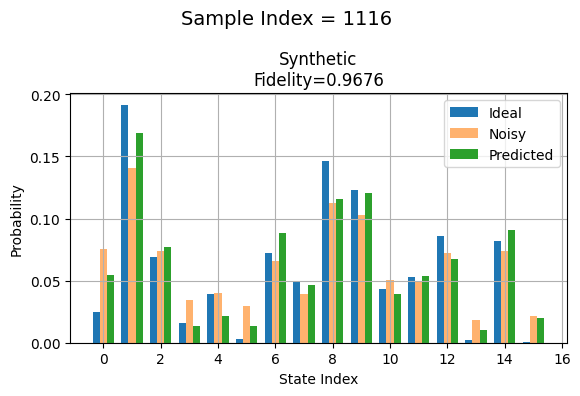

In [38]:
visualize_aligned_samples(model_phase3_0,
    datasets={"Synthetic":(X_test_syn_30, Y_test_syn_30)},
    n_samples=1)

#### Phase 3_1 
- TRAIN:
    - zzfeaturemap + experimental_single  


- VALIDATION:
    - zzfeaturemap + experimental_single

- TEST:
    - zzfeaturemap + experimental_single
    - zzfeaturemap + experimental_correlated 
    - independent  + synthetic 

In [39]:
X_train_31, Y_train_31, TH_train_31 = load_dataset(
    split="train",circuit_type="zz_featuremap",
    noise_mode="experimental_single")   
X_val_31, Y_val_31, TH_val_31 = load_dataset(
    split="validation",circuit_type="zz_featuremap",
    noise_mode="experimental_single")

X_test_single_31, Y_test_single_31, TH_test_single_31 = load_dataset(
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single")

In [40]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_31, dtype=torch.float32),
        torch.tensor(Y_train_31, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)

val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_31, dtype=torch.float32),
        torch.tensor(Y_val_31, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [41]:
model_phase3_1 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase3_1.parameters(),
    lr=1e-3)
EPOCHS = 61
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase3_1.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase3_1(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        # loss = criterion(preds, yb )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase3_1.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase3_1(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            # loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 0.4941 | Val Loss = 0.4707
Epoch 10 | Train Loss = 0.2267 | Val Loss = 0.2227
Epoch 20 | Train Loss = 0.1707 | Val Loss = 0.1698
Epoch 30 | Train Loss = 0.1443 | Val Loss = 0.1421
Epoch 40 | Train Loss = 0.1241 | Val Loss = 0.1235
Epoch 50 | Train Loss = 0.1120 | Val Loss = 0.1130
Epoch 60 | Train Loss = 0.1040 | Val Loss = 0.1042


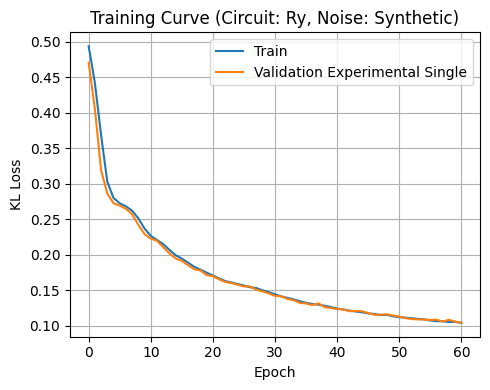

In [42]:
# Plot 
plt.figure(figsize=(5,4))
plt.plot(train_losses, label="Train")
plt.plot(val_losses,
         label="Validation Experimental Single")
plt.xlabel("Epoch")
plt.ylabel("KL Loss")
plt.title("Training Curve (Circuit: Ry, Noise: Synthetic)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
from src.evaluation import evaluate_model
import pandas as pd

# Phase 3_1: ZZ FeatureMap | matched train/test: Experimental Single
res = evaluate_model(model_phase3_1, X_test_single_31, Y_test_single_31)
df_3_1 = pd.DataFrame([{
    "Dataset": "experimental_single",
    "FidelityMean": round(res["fidelity_mean"], 3),
    "L1 Mean": round(res["l1_mean"], 3),
    "KL Mean": round(res["kl_mean"], 3),
}])
print("phase 3_1: ZZ FeatureMap | matched train/test: Experimental Single")
print("==========================================================")
print(df_3_1)

phase 3_1: ZZ FeatureMap | matched train/test: Experimental Single
               Dataset  FidelityMean  L1 Mean  KL Mean
0  experimental_single         0.939    0.322    0.108


Shared indices: [1116]


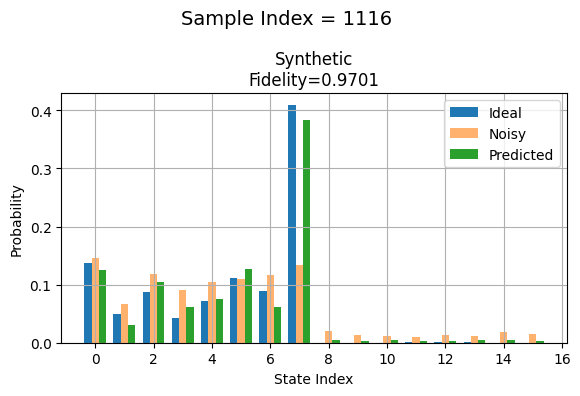

In [44]:
visualize_aligned_samples(model_phase3_1,
    datasets={"Synthetic":(X_test_single_31, Y_test_single_31)},
    n_samples=1)

In [45]:
# # if the noise even excecuted? 
# thetas = np.random.uniform(0,np.pi,4)

# p_ideal = get_probs(build_zzfeaturemap_circuit,
#     thetas, noise_model=None)

# p_noisy = get_probs(
#     build_zzfeaturemap_circuit,
#     thetas, noise_model=create_noise_model(
#         mode="experimental_single"))

# print(fidelity(p_ideal,p_noisy))
# print(np.max(np.abs(p_ideal-p_noisy)))

In [46]:
print(np.mean(np.max(Y_test_single_31, axis=1)))
print(np.mean(np.max(X_test_single_31, axis=1)))

0.24460416666666668
0.15230729166666668


In [47]:
purity_ind = np.mean([np.sum(y**2) for y in Y_test_syn_1])
print("purity_ind",purity_ind)



purity_ind 0.323609567006429


#### Phase 3_2
- train:
    - zz_featuremap + experimental_correlated
- VALIDATION:
    - zzfeaturemap + experimental_single
- TEST:
    - zzfeaturemap + experimental_single
    - zzfeaturemap + experimental_correlated 
    - zzfeaturemap  + synthetic 


In [48]:
X_train_32, Y_train_32, TH_train_32 = load_dataset(
    split="train", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

X_val_32, Y_val_32, TH_val_32 = load_dataset(
    split="validation", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

X_test_corr_32, Y_test_corr_32, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [49]:
# Fidelity before executing the training! 
raw_fidelity2 = np.mean([
    fidelity(Y_test_corr_32[i], X_test_corr_32[i])
    for i in range(len(X_test_corr_32))])
print(raw_fidelity2)

0.8607546498332759


In [50]:
# check fidelity without traing
fids_raw2 = []

fids_raw2 = np.mean([
    fidelity(Y_test_corr_32[i], X_test_corr_32[i])
    for i in range(len(X_test_corr_32))])

print('single',np.mean(fids_raw2))

single 0.8607546498332759


In [51]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_32, dtype=torch.float32),
        torch.tensor(Y_train_32, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)
# Validation Loader
val_loader = DataLoader(
    TensorDataset( torch.tensor(X_val_32, dtype=torch.float32),
        torch.tensor(Y_val_32, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [52]:
     
model_phase3_2 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase3_2.parameters(),
    lr=1e-3)
EPOCHS = 61
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase3_2.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase3_2(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        # loss = criterion(preds, yb )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase3_2.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase3_2(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            # loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 0.4894 | Val Loss = 0.4757
Epoch 10 | Train Loss = 0.1693 | Val Loss = 0.1630
Epoch 20 | Train Loss = 0.1200 | Val Loss = 0.1158
Epoch 30 | Train Loss = 0.0841 | Val Loss = 0.0830
Epoch 40 | Train Loss = 0.0642 | Val Loss = 0.0630
Epoch 50 | Train Loss = 0.0519 | Val Loss = 0.0515
Epoch 60 | Train Loss = 0.0435 | Val Loss = 0.0425


In [53]:
from src.evaluation import evaluate_model
import pandas as pd

# Phase 3_2 (KL loss): ZZ FeatureMap | matched train/test: Experimental Correlated
res = evaluate_model(model_phase3_2, X_test_corr_32, Y_test_corr_32)
df_3_2 = pd.DataFrame([{
    "Dataset": "experimental_correlated",
    "FidelityMean": round(res["fidelity_mean"], 3),
    "L1 Mean": round(res["l1_mean"], 3),
    "KL Mean": round(res["kl_mean"], 3),
}])
print("phase 3_2 (KL): ZZ FeatureMap | matched train/test: Experimental Correlated")
print("==========================================================")
print(df_3_2)

phase 3_2 (KL): ZZ FeatureMap | matched train/test: Experimental Correlated
                   Dataset  FidelityMean  L1 Mean  KL Mean
0  experimental_correlated         0.974    0.178    0.044


In [54]:
results_32 = {}
results_32["experimental_correlated"] = evaluate_model(   
    model_phase3_2, X_test_corr_32, Y_test_corr_32)
import pandas as pd
rows = []
for name, res in results_32.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_3_2 = pd.DataFrame(rows)
print("phase 3_2:(MSE) circuit zz, Noise: correlated")
print('==========================================================')
print(df_3_2)

phase 3_2:(MSE) circuit zz, Noise: correlated
                   Dataset  FidelityMean  L1 Mean  KL Mean
0  experimental_correlated         0.974    0.178    0.044


Shared indices: [1116]


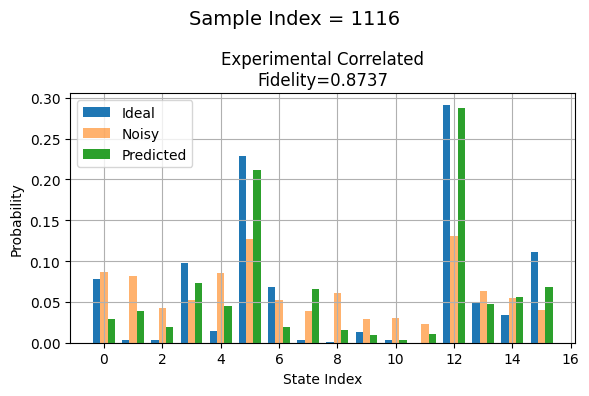

In [55]:
visualize_aligned_samples(model_phase3_2,
    datasets={"Experimental Correlated":(X_test_corr_32, Y_test_corr_32)},
    n_samples=1)

# visualize_aligned_samples(model_phase3_2,
#     X_test_syn_32, Y_test_syn_32,
#     X_test_single_32, Y_test_single_32,
#     X_test_corr_32, Y_test_corr_32,
#     n_samples=1)

### Oganize outputs

In [60]:
from src.evaluation import make_test_sets

# --- Independent circuit ---
# baseline: all 3 noises | each phase: only its matched noise
indep_baseline = make_test_sets(
    synthetic=(X_test_syn_1, Y_test_syn_1),
    experimental_single=(X_test_single_1, Y_test_single_1),
    experimental_correlated=(X_test_corr_1, Y_test_corr_1),
)
test_sets_phase1 = make_test_sets(synthetic=(X_test_syn_1, Y_test_syn_1))
test_sets_phase2_0 = make_test_sets(
    experimental_single=(X_test_single_2, Y_test_single_2))
test_sets_phase2_1 = make_test_sets(
    experimental_correlated=(X_test_corr_2_1, Y_test_corr_2_1))

# --- ZZ FeatureMap circuit ---
zz_baseline = make_test_sets(
    synthetic=(X_test_syn_30, Y_test_syn_30),
    experimental_single=(X_test_single_30, Y_test_single_30),
    experimental_correlated=(X_test_corr_30, Y_test_corr_30),
)
test_sets_phase3_0 = make_test_sets(synthetic=(X_test_syn_30, Y_test_syn_30))
test_sets_phase3_1 = make_test_sets(
    experimental_single=(X_test_single_31, Y_test_single_31))
test_sets_phase3_2 = make_test_sets(
    experimental_correlated=(X_test_corr_32, Y_test_corr_32))

In [61]:
import importlib
import src.evaluation
import src.dashboard
importlib.reload(src.evaluation)
importlib.reload(src.dashboard)
from src.evaluation import run_matched_tests
from src.dashboard import (
    build_matched_comparison_df,
    show_all_matched_tables,
    plot_fidelity_bars,
    matched_metrics_dashboard,
)
from src.registery import EXPERIMENTS

In [62]:
EXPERIMENTS.clear()

# Baseline: no training -> all 3 noise types per circuit
run_matched_tests(model_base, EXPERIMENTS,
    circuit="Independent", training_noise="No Training",
    test_sets=indep_baseline)
run_matched_tests(model_base_zz, EXPERIMENTS,
    circuit="ZZ FeatureMap", training_noise="No Training",
    test_sets=zz_baseline)

# Trained phases: only matched noise (filtered inside run_matched_tests)
run_matched_tests(model_phase1, EXPERIMENTS,
    circuit="Independent", training_noise="Synthetic",
    test_sets=test_sets_phase1)
run_matched_tests(model_phase2_0, EXPERIMENTS,
    circuit="Independent", training_noise="Experimental Single",
    test_sets=test_sets_phase2_0)
run_matched_tests(model_phase2_1, EXPERIMENTS,
    circuit="Independent", training_noise="Experimental Correlated",
    test_sets=test_sets_phase2_1)
run_matched_tests(model_phase3_0, EXPERIMENTS,
    circuit="ZZ FeatureMap", training_noise="Synthetic",
    test_sets=test_sets_phase3_0)
run_matched_tests(model_phase3_1, EXPERIMENTS,
    circuit="ZZ FeatureMap", training_noise="Experimental Single",
    test_sets=test_sets_phase3_1)
run_matched_tests(model_phase3_2, EXPERIMENTS,
    circuit="ZZ FeatureMap", training_noise="Experimental Correlated",
    test_sets=test_sets_phase3_2)

In [78]:
importlib.reload(src.dashboard)
from src.dashboard import build_matched_comparison_df, show_all_matched_tables
from src.dashboard import build_matched_comparison_df, show_all_matched_tables

comparison_df = build_matched_comparison_df(EXPERIMENTS)

# جدول baseline vs trained برای هر سه معیار (نویز train/test منطبق)
show_all_matched_tables(comparison_df)


================ FidelityMean | Fidelity (higher = better) (matched train/test) ================
      Circuit                   Noise  Baseline  Trained  Delta
  Independent               Synthetic     0.907    0.979  0.072
  Independent     Experimental Single     0.768    0.968  0.200
  Independent Experimental Correlated     0.763    0.984  0.221
ZZ FeatureMap               Synthetic     0.938    0.973  0.035
ZZ FeatureMap     Experimental Single     0.853    0.939  0.085
ZZ FeatureMap Experimental Correlated     0.861    0.974  0.113

================ L1Mean | L1 Error (lower = better) (matched train/test) ================
      Circuit                   Noise  Baseline  Trained  Delta
  Independent               Synthetic     0.367    0.147  0.220
  Independent     Experimental Single     0.707    0.190  0.517
  Independent Experimental Correlated     0.714    0.117  0.596
ZZ FeatureMap               Synthetic     0.323    0.205  0.119
ZZ FeatureMap     Experimental Single     0

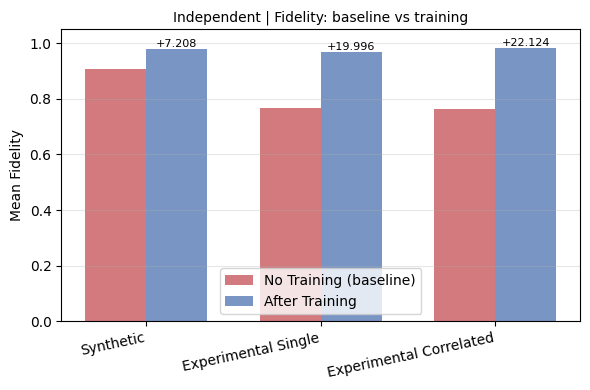

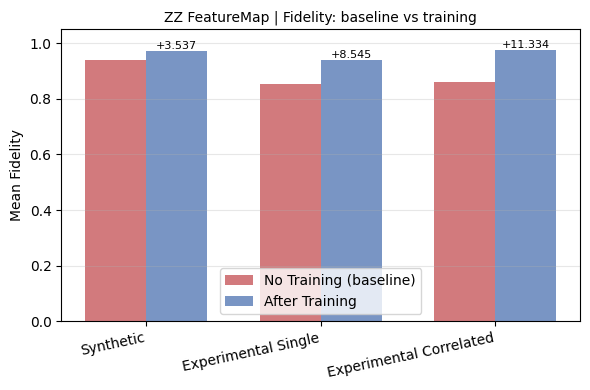

In [97]:
# نمودار ستونی fidelity: baseline (بدون آموزش) در برابر پس از آموزش منطبق
importlib.reload(src.dashboard)
from src.dashboard import plot_fidelity_bars
plot_fidelity_bars(comparison_df)

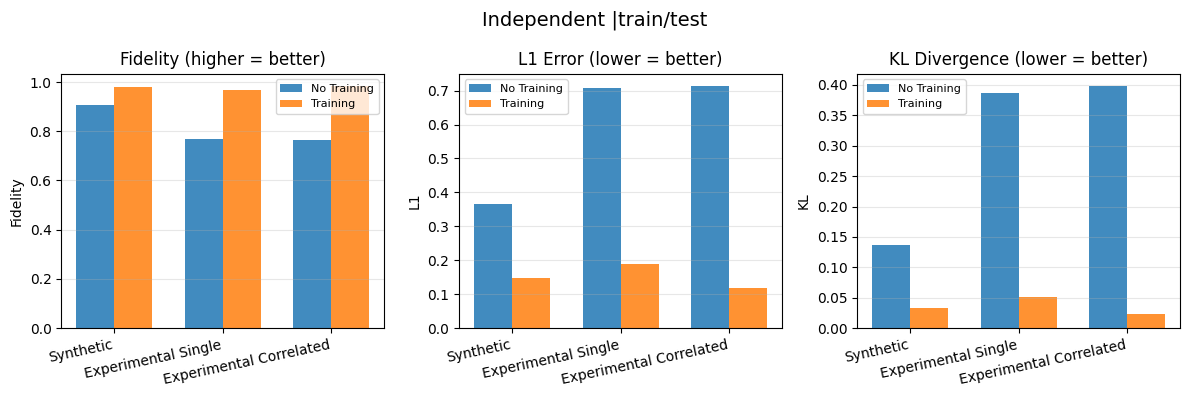

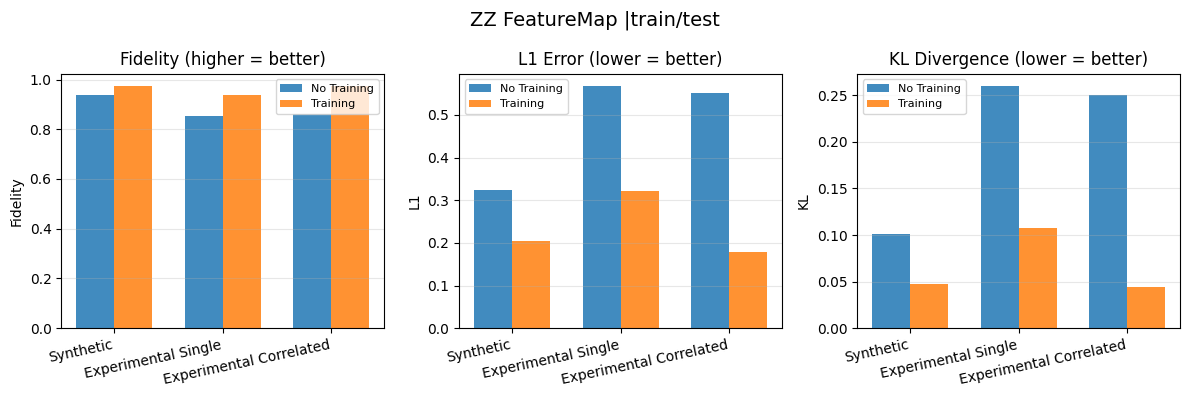

In [85]:
# داشبورد هر سه معیار (L1 و KL هم baseline vs trained)
importlib.reload(src.dashboard)
from src.dashboard import matched_metrics_dashboard
matched_metrics_dashboard(comparison_df)

In [67]:
# full_dashboard(summary_df, metric="FidelityMean")

##### Display results

In [68]:
df_zz_raw = pd.DataFrame({
    "Dataset": [
        "synthetic",
        "experimental_single",
        "experimental_correlated"],
    "FidelityMean": [
        np.mean([
            fidelity(Y_test_syn_32[i], X_test_syn_32[i])
            for i in range(len(X_test_syn_32))]),
        np.mean([
            fidelity(Y_test_single_32[i], X_test_single_32[i])
            for i in range(len(X_test_single_32))]),
        np.mean([
            fidelity(Y_test_corr_32[i], X_test_corr_32[i])
            for i in range(len(X_test_corr_32))]) ]})

NameError: name 'X_test_syn_32' is not defined

In [ ]:
import pandas as pd

phases = {
    ("Independent", "No Training"): df_0,
    ("Independent", "Synthetic"): df_1,
    ("Independent", "Experimental Single"): df_2_0,
    ("Independent", "Experimental Correlated"): df_2_1,
    ("ZZ FeatureMap", "No Training"): df_zz_raw,
    ("ZZ FeatureMap", "Synthetic"): df_3_0,
    ("ZZ FeatureMap", "Experimental Single"): df_3_1,
    ("ZZ FeatureMap", "Experimental Correlated"): df_3_2,}
rows = []
for (circuit, training_noise), df in phases.items():
    row = {"Circuit": circuit,"Training Noise": training_noise }
    for _, r in df.iterrows():
        dataset = r["Dataset"]
        if dataset == "synthetic":
            row["Synthetic"] = r["FidelityMean"]
        elif dataset == "experimental_single":
            row["Experimental Single"] = r["FidelityMean"]
        elif dataset == "experimental_correlated":
            row["Experimental Correlated"] = r["FidelityMean"]
    rows.append(row)
summary_df = pd.DataFrame(rows)
summary_df = summary_df[["Circuit","Training Noise",
    "Synthetic","Experimental Single",
    "Experimental Correlated" ]]
summary_df = summary_df.set_index(["Circuit", "Training Noise"])
print(summary_df.round(3).to_string())

In [ ]:
import numpy as np
def compute_metrics(preds, Y):
    fidelities = []
    l1s = []
    kls = []
    for i in range(len(preds)):
        p = preds[i]
        y = Y[i]
        # Fidelity
        fid = (np.sum(np.sqrt(p * y))) ** 2
        # L1 distance
        l1 = np.sum(np.abs(p - y))
        # KL divergence (safe version)
        kl = np.sum(
            y * np.log((y + 1e-10) / (p + 1e-10)) )
        fidelities.append(fid)
        l1s.append(l1)
        kls.append(kl)
    return {
        "FidelityMean": float(np.mean(fidelities)),
        "L1Mean": float(np.mean(l1s)),
        "KLMean": float(np.mean(kls)),
        # "FidelityStd": float(np.std(fidelities)),
        # "L1Std": float(np.std(l1s)),
        # "KLStd": float(np.std(kls)),
    }

In [ ]:
results_0 = {}
for noise_mode in noise_modes:
    X_test, Y_test, TH_test = load_dataset(
        split="test",
        circuit_type="independent",
        noise_mode=noise_mode )
    preds = model_base(X_test)  # یا batch inference
    results_0[noise_mode] = compute_metrics(preds, Y_test)
rows = []
for noise_mode, metrics in results_0.items():
    rows.append({
        "Dataset": noise_mode,
        **metrics})
df_0 = pd.DataFrame(rows)
df_0

### Generate and Save datasets

In [ ]:
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="independent",
    noise_mode="synthetic")
# about 17 min

In [ ]:
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="independent",
    noise_mode="experimental_single")
# Next
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="independent",
    noise_mode="experimental_correlated")

In [ ]:
# done
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="independent",
    noise_mode="experimental_correlated")

In [ ]:
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [ ]:
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single")

In [ ]:
# TEST:
#     independent + experimental_single
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="independent",
    noise_mode="experimental_single")

In [ ]:
# Test 1
X_test_base, Y_test_base, TH_test_base = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="independent",
    noise_mode="synthetic")

In [ ]:
# Test Done!
X_test_fmap, Y_test_fmap, TH_test_fmap = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 1,"entanglement": "full"})

In [ ]:
# VALIDATION: Done!
#     independent + experimental_correlated
X_val2, Y_val2, TH_val2 = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="independent",
    noise_mode="experimental_correlated")

In [ ]:
# test Done!
# independent + experimental_correlated
X_test_B, Y_test_B, TH_test_B = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="independent",
    noise_mode="experimental_correlated")

In [ ]:
# VALIDATION:
#     independent + experimental_single
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="independent",
    noise_mode="synthetic")

In [ ]:
#  Done!
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# done
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# done
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# Done 
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# here
X_va1, Y_va1, TH_va1 = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="synthetic",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# here
X_1, Y_1, TH_1 = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# done
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# done
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="synthetic",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# done
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="zz_featuremap",
    noise_mode="synthetic",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# Generate diverse data set for zz_featuremap
# by parameters reps and theta range ---> reps: 1, 2 and theta range: [0, pi], [0, 2pi]

In [ ]:
X_test_corr, Y_test_corr, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [ ]:
purity_ind = np.mean([np.sum(y**2) for y in Y_test_syn_1])
print("purity_ind",purity_ind)

purity_zz = np.mean([np.sum(y2**2) for y2 in Y_test_corr])
print("purity_zz",purity_zz)

In [ ]:
# reps= 2 and theta range: [0, pi/4]
X_test_fmap, Y_test_fmap, TH_test_fmap = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
X_test_corr2, Y_test_corr2, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [ ]:
purity_ind = np.mean([np.sum(y**2) for y in Y_test_syn_1])
print("purity_ind",purity_ind)

purity_zz2 = np.mean([np.sum(y3**2) for y3 in Y_test_corr2])
print("purity_zz2",purity_zz2)

In [ ]:
X_test_corr, Y_test_corr, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [ ]:
raw_fidelity = np.mean([
    fidelity(Y_test_corr[i], X_test_corr[i])
    for i in range(len(X_test_corr))])
print(raw_fidelity)

##### Save datasetsm